# Dự đoán lỗi phần mềm trên bộ dữ liệu NASA/PROMISE

## 1. Giới thiệu

Các mô hình được đánh giá gồm:

- Decision Tree
- Logistic Regression
- Support Vector Machine
- Random Forest
- AdaBoost
- Bagging


## 2. Import thư viện


In [1]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 300

RANDOM_STATE = 20
DATA_PATH = Path('data.csv')
TARGET_COLUMN = 'Defective'


## 3. Nạp dữ liệu


In [2]:
raw_df = pd.read_csv(DATA_PATH)

print(f'Shape: {raw_df.shape}')
raw_df.head()


Shape: (15196, 22)


,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,HALSTEAD_DIFFICULTY,...,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL,Defective
0,1,7,0,0,4,3,1,11,25.05,11.20,...,59,0.09,174.56,280.54,28,31,15,12,14,0
1,5,37,0,6,19,16,10,85,81.19,27.41,...,351,0.04,3388.22,2225.29,147,204,59,22,98,0
2,2,1,0,0,1,1,1,10,56.44,2.83,...,37,0.35,25.17,159.91,17,20,15,5,14,1
3,16,1,0,0,1,1,1,52,168.57,16.97,...,450,0.06,2697.42,2860.90,198,252,70,12,70,1
4,0,7,0,0,4,2,3,9,14.32,7.71,...,26,0.13,47.33,110.45,9,17,7,12,12,0


## 4. Phân tích khám phá dữ liệu (EDA)


In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15196 entries, 0 to 15195
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LOC_BLANK              15196 non-null  int64  
 1   BRANCH_COUNT           15196 non-null  int64  
 2   LOC_CODE_AND_COMMENT   15196 non-null  int64  
 3   LOC_COMMENTS           15196 non-null  int64  
 4   CYCLOMATIC_COMPLEXITY  15196 non-null  int64  
 5   DESIGN_COMPLEXITY      15196 non-null  int64  
 6   ESSENTIAL_COMPLEXITY   15196 non-null  int64  
 7   LOC_EXECUTABLE         15196 non-null  int64  
 8   HALSTEAD_CONTENT       15196 non-null  float64
 9   HALSTEAD_DIFFICULTY    15196 non-null  float64
 10  HALSTEAD_EFFORT        15196 non-null  float64
 11  HALSTEAD_ERROR_EST     15196 non-null  float64
 12  HALSTEAD_LENGTH        15196 non-null  int64  
 13  HALSTEAD_LEVEL         15196 non-null  float64
 14  HALSTEAD_PROG_TIME     15196 non-null  float64
 15  HALSTEAD_VOLU

In [4]:
raw_df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
LOC_BLANK,15196.0,7.213872,16.836134,0.0,1.0000,3.000,8.0000,704.00
BRANCH_COUNT,15196.0,11.915965,24.874548,1.0,3.0000,5.000,13.0000,826.00
LOC_CODE_AND_COMMENT,15196.0,1.423006,4.834306,0.0,0.0000,0.000,1.0000,180.00
LOC_COMMENTS,15196.0,5.901356,20.540093,0.0,0.0000,0.000,5.0000,901.00
CYCLOMATIC_COMPLEXITY,15196.0,6.628718,13.720208,1.0,2.0000,3.000,7.0000,470.00
DESIGN_COMPLEXITY,15196.0,4.012437,8.659204,1.0,1.0000,2.000,4.0000,402.00
ESSENTIAL_COMPLEXITY,15196.0,3.208739,7.203414,1.0,1.0000,1.000,3.0000,290.00
LOC_EXECUTABLE,15196.0,34.166952,81.098657,0.0,9.0000,17.000,34.0000,2824.00
HALSTEAD_CONTENT,15196.0,39.970063,142.812427,0.0,16.7100,26.510,43.0025,14763.91
HALSTEAD_DIFFICULTY,15196.0,18.199852,22.669567,0.0,7.0000,12.500,22.3100,833.78


,count,ratio
Defective,,
Non-defective,12513,0.8234
Defective,2683,0.1766


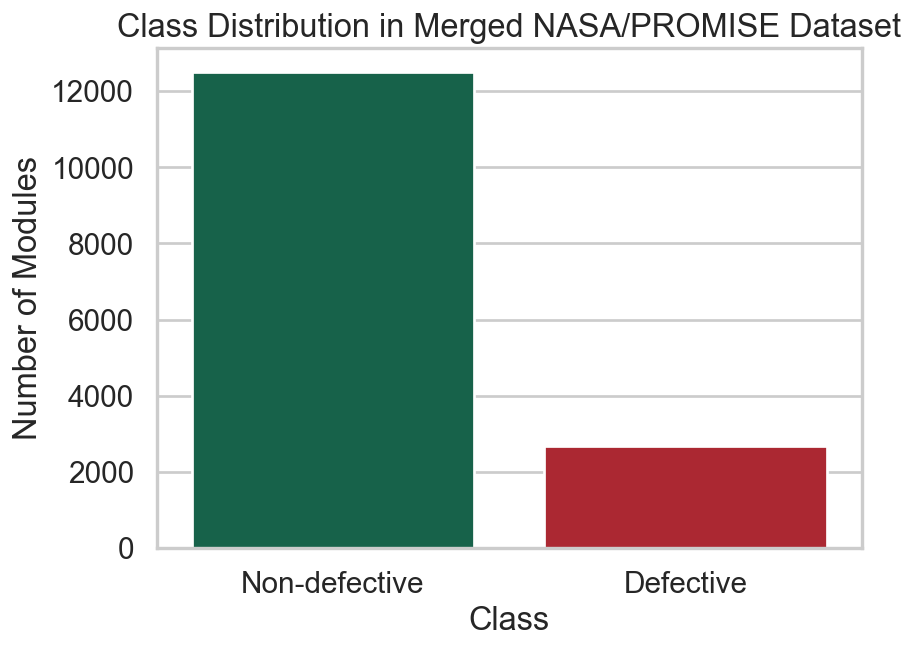

In [5]:
target_distribution = raw_df[TARGET_COLUMN].value_counts(dropna=False).sort_index()
target_ratio = raw_df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
display(pd.DataFrame({
    'count': target_distribution,
    'ratio': target_ratio.round(4)
}).rename(index={0: 'Non-defective', 1: 'Defective'}));

plt.figure(figsize=(7, 5))
class_labels = raw_df[TARGET_COLUMN].map({0: 'Non-defective', 1: 'Defective'})
sns.countplot(x=class_labels, hue=class_labels, palette=['#0b6e4f', '#c1121f'], legend=False)
plt.title('Class Distribution in Merged NASA/PROMISE Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Modules')
plt.show()


In [6]:
quality_report = []
for col in raw_df.columns:
    question_marks = int((raw_df[col].astype(str) == '?').sum())
    quality_report.append({
        'column': col,
        'dtype': str(raw_df[col].dtype),
        'missing_values': int(raw_df[col].isna().sum()),
        'question_mark_values': question_marks,
    })
quality_report_df = pd.DataFrame(quality_report)
question_mark_columns = quality_report_df.loc[
    quality_report_df['question_mark_values'] > 0,
    'column'
].tolist()
quality_report_df[(quality_report_df['missing_values'] > 0) | (quality_report_df['question_mark_values'] > 0)]


,column,dtype,missing_values,question_mark_values


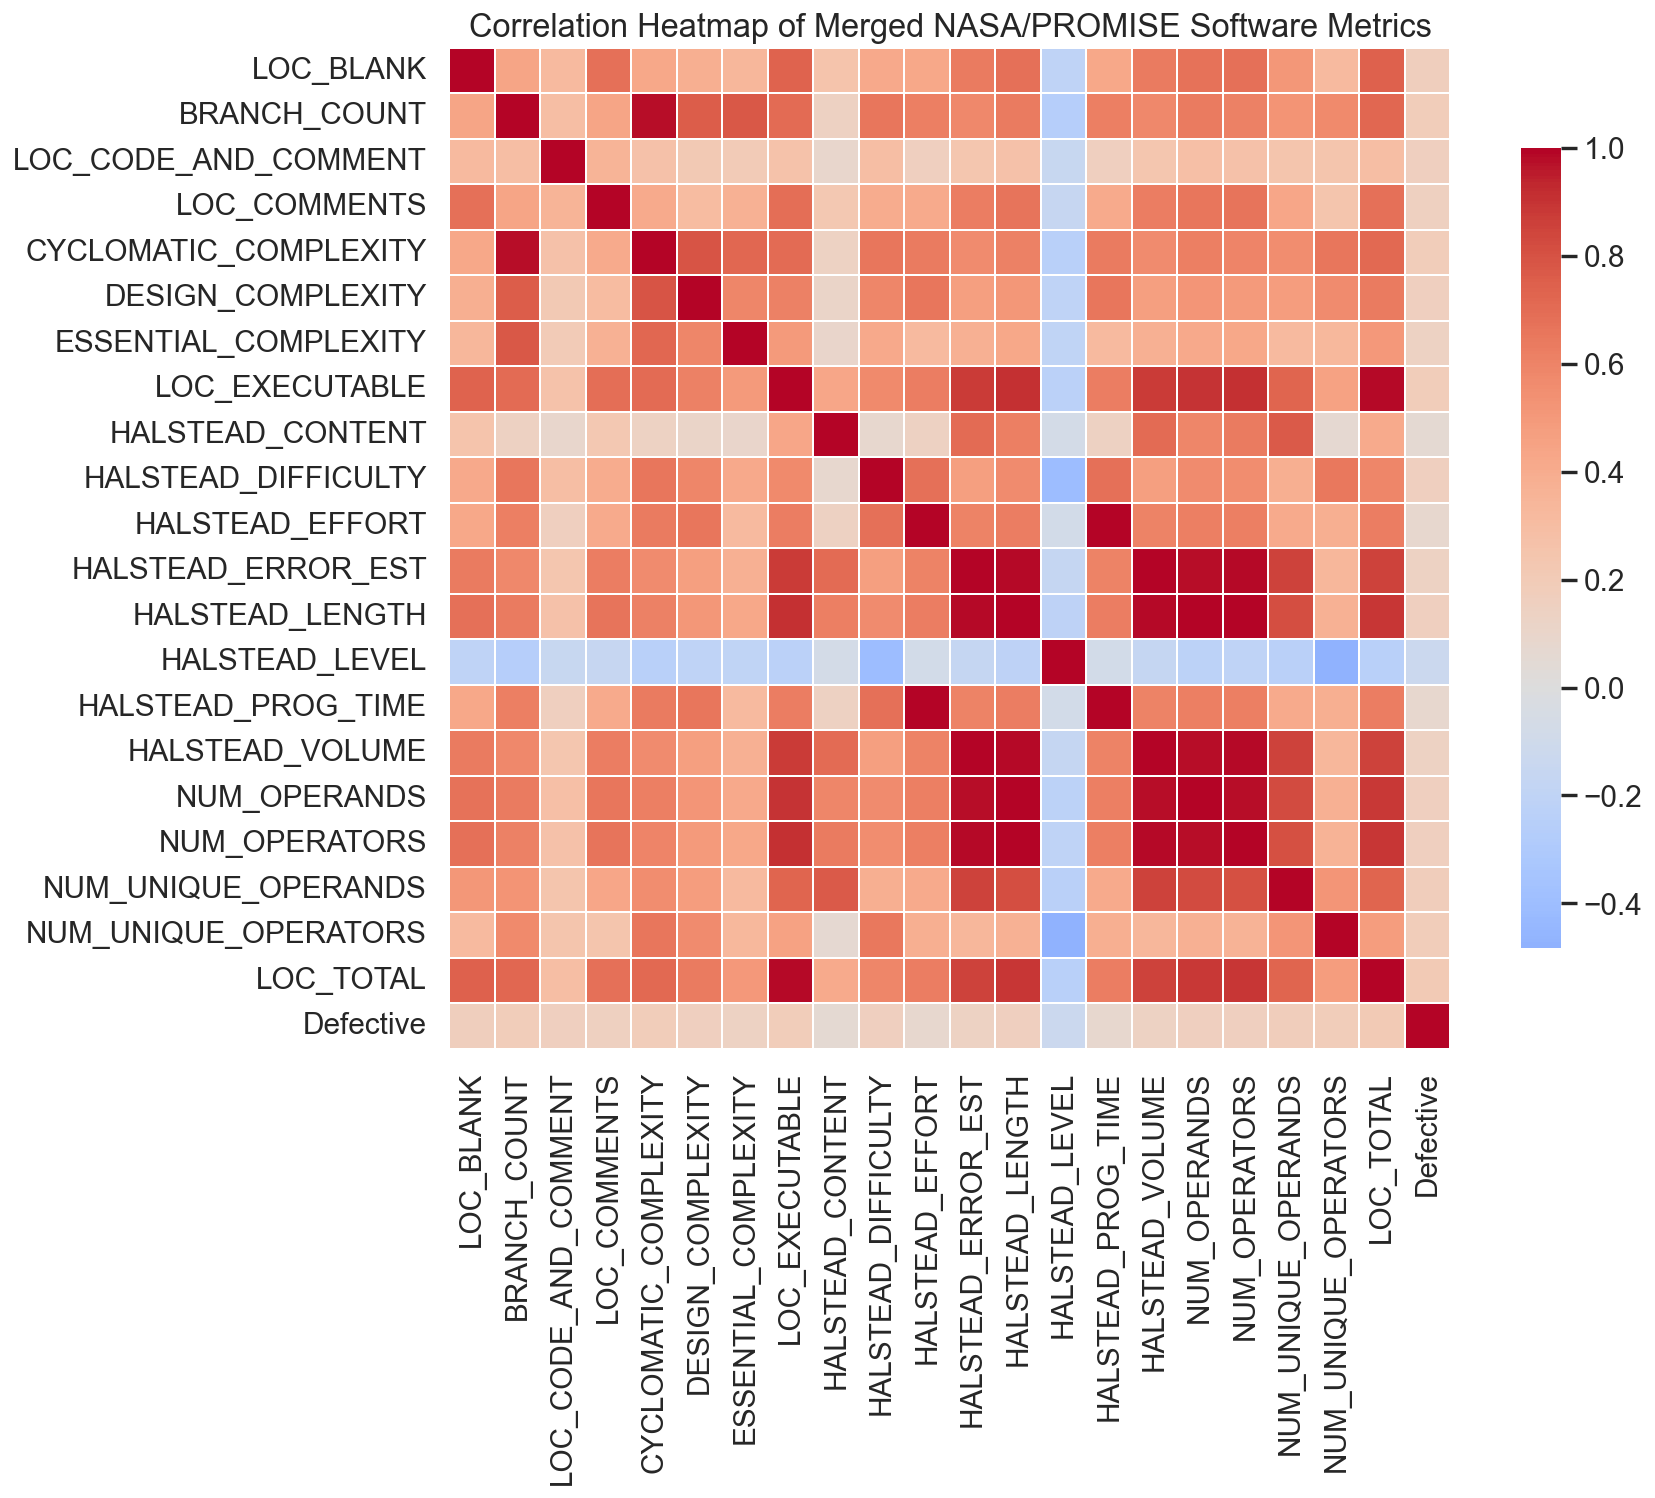

In [7]:
eda_numeric = raw_df.copy()
for col in question_mark_columns:
    eda_numeric[col] = pd.to_numeric(eda_numeric[col], errors='coerce')
eda_numeric[TARGET_COLUMN] = eda_numeric[TARGET_COLUMN].astype(int)

plt.figure(figsize=(14, 10))
corr = eda_numeric.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.2, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Merged NASA/PROMISE Software Metrics')
plt.show()


## 5. Tiền xử lý dữ liệu


In [8]:
def clean_defect_dataset(df: pd.DataFrame, target_column: str = TARGET_COLUMN) -> tuple[pd.DataFrame, pd.DataFrame]:
    cleaned = df.copy()
    report = []
    for col in cleaned.columns:
        if col != target_column:
            before_missing = int(cleaned[col].isna().sum())
            cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
            after_coerce_missing = int(cleaned[col].isna().sum())
            imputed = after_coerce_missing
            if cleaned[col].isna().any():
                cleaned[col] = cleaned[col].fillna(cleaned[col].median())
            report.append({
                'column': col,
                'missing_before': before_missing,
                'missing_after_coercion': after_coerce_missing,
                'imputed_values': imputed,
            })
    cleaned[target_column] = cleaned[target_column].astype(int)
    return cleaned, pd.DataFrame(report)

clean_df, preprocessing_report = clean_defect_dataset(raw_df)
print(f'Cleaned shape: {clean_df.shape}')
clean_df.head()


Cleaned shape: (15196, 22)


,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,HALSTEAD_DIFFICULTY,...,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL,Defective
0,1,7,0,0,4,3,1,11,25.05,11.20,...,59,0.09,174.56,280.54,28,31,15,12,14,0
1,5,37,0,6,19,16,10,85,81.19,27.41,...,351,0.04,3388.22,2225.29,147,204,59,22,98,0
2,2,1,0,0,1,1,1,10,56.44,2.83,...,37,0.35,25.17,159.91,17,20,15,5,14,1
3,16,1,0,0,1,1,1,52,168.57,16.97,...,450,0.06,2697.42,2860.90,198,252,70,12,70,1
4,0,7,0,0,4,2,3,9,14.32,7.71,...,26,0.13,47.33,110.45,9,17,7,12,12,0


In [9]:
preprocessing_report[preprocessing_report['imputed_values'] > 0]

,column,missing_before,missing_after_coercion,imputed_values


In [10]:
dataset_summary = pd.DataFrame({
    'Statistic': [
        'Number of instances',
        'Number of features',
        'Defective modules',
        'Non-defective modules',
        'Defective ratio',
        'Non-defective ratio',
        'Remaining missing values',
    ],
    'Value': [
        len(clean_df),
        clean_df.shape[1] - 1,
        int(clean_df[TARGET_COLUMN].sum()),
        int((1 - clean_df[TARGET_COLUMN]).sum()),
        round(clean_df[TARGET_COLUMN].mean(), 4),
        round(1 - clean_df[TARGET_COLUMN].mean(), 4),
        int(clean_df.isna().sum().sum()),
    ]
})
dataset_summary


,Statistic,Value
0,Number of instances,15196.0000
1,Number of features,21.0000
2,Defective modules,2683.0000
3,Non-defective modules,12513.0000
4,Defective ratio,0.1766
5,Non-defective ratio,0.8234
6,Remaining missing values,0.0000


## 6. Xử lý mất cân bằng lớp bằng SMOTE


In [11]:
X = clean_df.drop(columns=[TARGET_COLUMN])
y = clean_df[TARGET_COLUMN]

print('Original class distribution:')
print(y.value_counts())

scaler_demo = StandardScaler()
X_scaled_demo = scaler_demo.fit_transform(X)
smote_demo = SMOTE(random_state=RANDOM_STATE)
X_smote_demo, y_smote_demo = smote_demo.fit_resample(X_scaled_demo, y)
print('\nSMOTE demo distribution:')
print(pd.Series(y_smote_demo).value_counts())


Original class distribution:
Defective
0    12513
1     2683
Name: count, dtype: int64

SMOTE demo distribution:
Defective
0    12513
1    12513
Name: count, dtype: int64


## 7. Định nghĩa mô hình


In [12]:
def build_models() -> Dict[str, object]:
    return {
        'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE),
        'Logistic Regression': LogisticRegression(C=1.0, solver='liblinear', max_iter=2000, random_state=RANDOM_STATE),
        'SVM': SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1),
        'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE),
        'Bagging': BaggingClassifier(
            estimator=DecisionTreeClassifier(min_samples_leaf=2, random_state=RANDOM_STATE),
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    }

models = build_models()
list(models.keys())

['Decision Tree',
 'Logistic Regression',
 'SVM',
 'Random Forest',
 'AdaBoost',
 'Bagging']

## 8. Huấn luyện mô hình bằng Stratified 10-Fold Cross Validation


In [13]:
def score_fold(y_true, y_pred, y_score):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
    }

def evaluate_models_cv(X: pd.DataFrame, y: pd.Series, models: Dict[str, object], n_splits: int = 10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    smote = SMOTE(random_state=RANDOM_STATE)
    mean_fpr = np.linspace(0, 1, 200)
    fold_records = []
    roc_records = []
    confusion_records = []
    final_models = {}

    for model_name, model in models.items():
        print(f'Evaluating {model_name}...')
        tprs = []
        cm_sum = np.zeros((2, 2), dtype=int)

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

            fitted_model = clone(model)
            fitted_model.fit(X_train_resampled, y_train_resampled)

            y_pred = fitted_model.predict(X_test_scaled)
            if hasattr(fitted_model, 'predict_proba'):
                y_score = fitted_model.predict_proba(X_test_scaled)[:, 1]
            else:
                decision = fitted_model.decision_function(X_test_scaled)
                y_score = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

            metrics = score_fold(y_test, y_pred, y_score)
            metrics.update({'model': model_name, 'fold': fold_idx})
            fold_records.append(metrics)

            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            cm_sum += cm

            fpr, tpr, _ = roc_curve(y_test, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        roc_records.append(pd.DataFrame({'model': model_name, 'fpr': mean_fpr, 'tpr': mean_tpr}))
        confusion_records.append({
            'model': model_name,
            'tn': int(cm_sum[0, 0]),
            'fp': int(cm_sum[0, 1]),
            'fn': int(cm_sum[1, 0]),
            'tp': int(cm_sum[1, 1]),
        })

        final_scaler = StandardScaler()
        X_scaled_full = final_scaler.fit_transform(X)
        X_full_resampled, y_full_resampled = smote.fit_resample(X_scaled_full, y)
        final_model = clone(model)
        final_model.fit(X_full_resampled, y_full_resampled)
        final_models[model_name] = {'model': final_model, 'scaler': final_scaler}

    fold_metrics_df = pd.DataFrame(fold_records)
    summary_df = (
        fold_metrics_df.groupby('model')
        .agg(
            accuracy_mean=('accuracy', 'mean'),
            accuracy_std=('accuracy', 'std'),
            precision_weighted_mean=('precision_weighted', 'mean'),
            recall_weighted_mean=('recall_weighted', 'mean'),
            f1_weighted_mean=('f1_weighted', 'mean'),
            roc_auc_mean=('roc_auc', 'mean'),
        )
        .reset_index()
        .sort_values(by='f1_weighted_mean', ascending=False)
    )

    return {
        'fold_metrics': fold_metrics_df,
        'summary_metrics': summary_df,
        'roc_curve': pd.concat(roc_records, ignore_index=True),
        'confusion_matrix': pd.DataFrame(confusion_records),
        'final_models': final_models,
    }

In [14]:
results = evaluate_models_cv(X, y, models, n_splits=10)
fold_metrics_df = results['fold_metrics']
summary_metrics_df = results['summary_metrics']
roc_curve_df = results['roc_curve']
confusion_df = results['confusion_matrix']

summary_metrics_df

Evaluating Decision Tree...
Evaluating Logistic Regression...
Evaluating SVM...
Evaluating Random Forest...
Evaluating AdaBoost...
Evaluating Bagging...


,model,accuracy_mean,accuracy_std,precision_weighted_mean,recall_weighted_mean,f1_weighted_mean,roc_auc_mean
4,Random Forest,0.818900,0.005633,0.804296,0.818900,0.810042,0.769000
1,Bagging,0.818770,0.009145,0.797440,0.818770,0.804616,0.753878
3,Logistic Regression,0.725389,0.012266,0.787209,0.725389,0.748288,0.711882
5,SVM,0.722361,0.012623,0.792319,0.722361,0.747260,0.723359
2,Decision Tree,0.691040,0.017537,0.779209,0.691040,0.721598,0.692011
0,AdaBoost,0.672413,0.019050,0.787755,0.672413,0.708397,0.713809


## 9. Đánh giá mô hình


In [15]:
summary_metrics_df.style.format({
    'accuracy_mean': '{:.4f}',
    'accuracy_std': '{:.4f}',
    'precision_weighted_mean': '{:.4f}',
    'recall_weighted_mean': '{:.4f}',
    'f1_weighted_mean': '{:.4f}',
    'roc_auc_mean': '{:.4f}',
})

,model,accuracy_mean,accuracy_std,precision_weighted_mean,recall_weighted_mean,f1_weighted_mean,roc_auc_mean
4,Random Forest,0.8189,0.0056,0.8043,0.8189,0.8100,0.7690
1,Bagging,0.8188,0.0091,0.7974,0.8188,0.8046,0.7539
3,Logistic Regression,0.7254,0.0123,0.7872,0.7254,0.7483,0.7119
5,SVM,0.7224,0.0126,0.7923,0.7224,0.7473,0.7234
2,Decision Tree,0.6910,0.0175,0.7792,0.6910,0.7216,0.6920
0,AdaBoost,0.6724,0.0190,0.7878,0.6724,0.7084,0.7138


## 10. Trực quan hóa


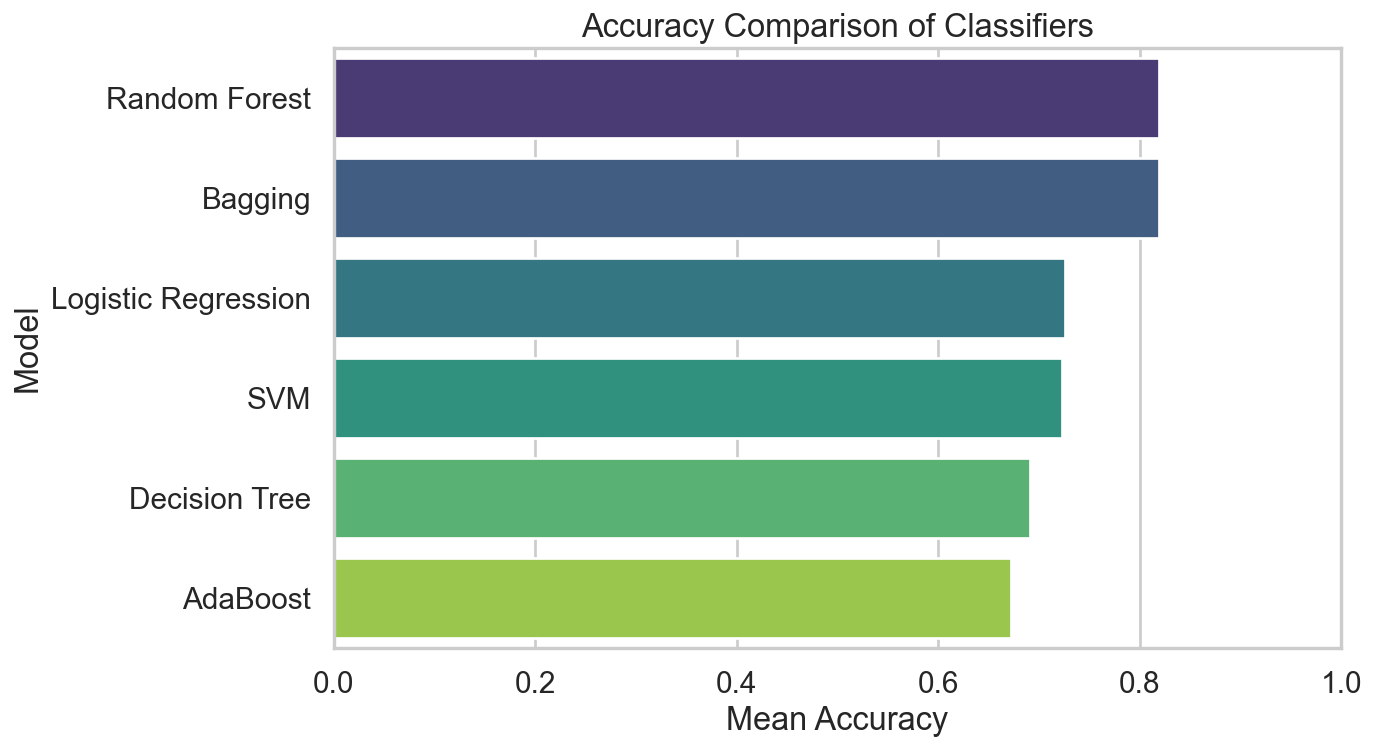

In [16]:
plot_df = summary_metrics_df.sort_values(by='accuracy_mean', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='accuracy_mean', y='model', hue='model', palette='viridis', legend=False)
plt.title('Accuracy Comparison of Classifiers')
plt.xlabel('Mean Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()


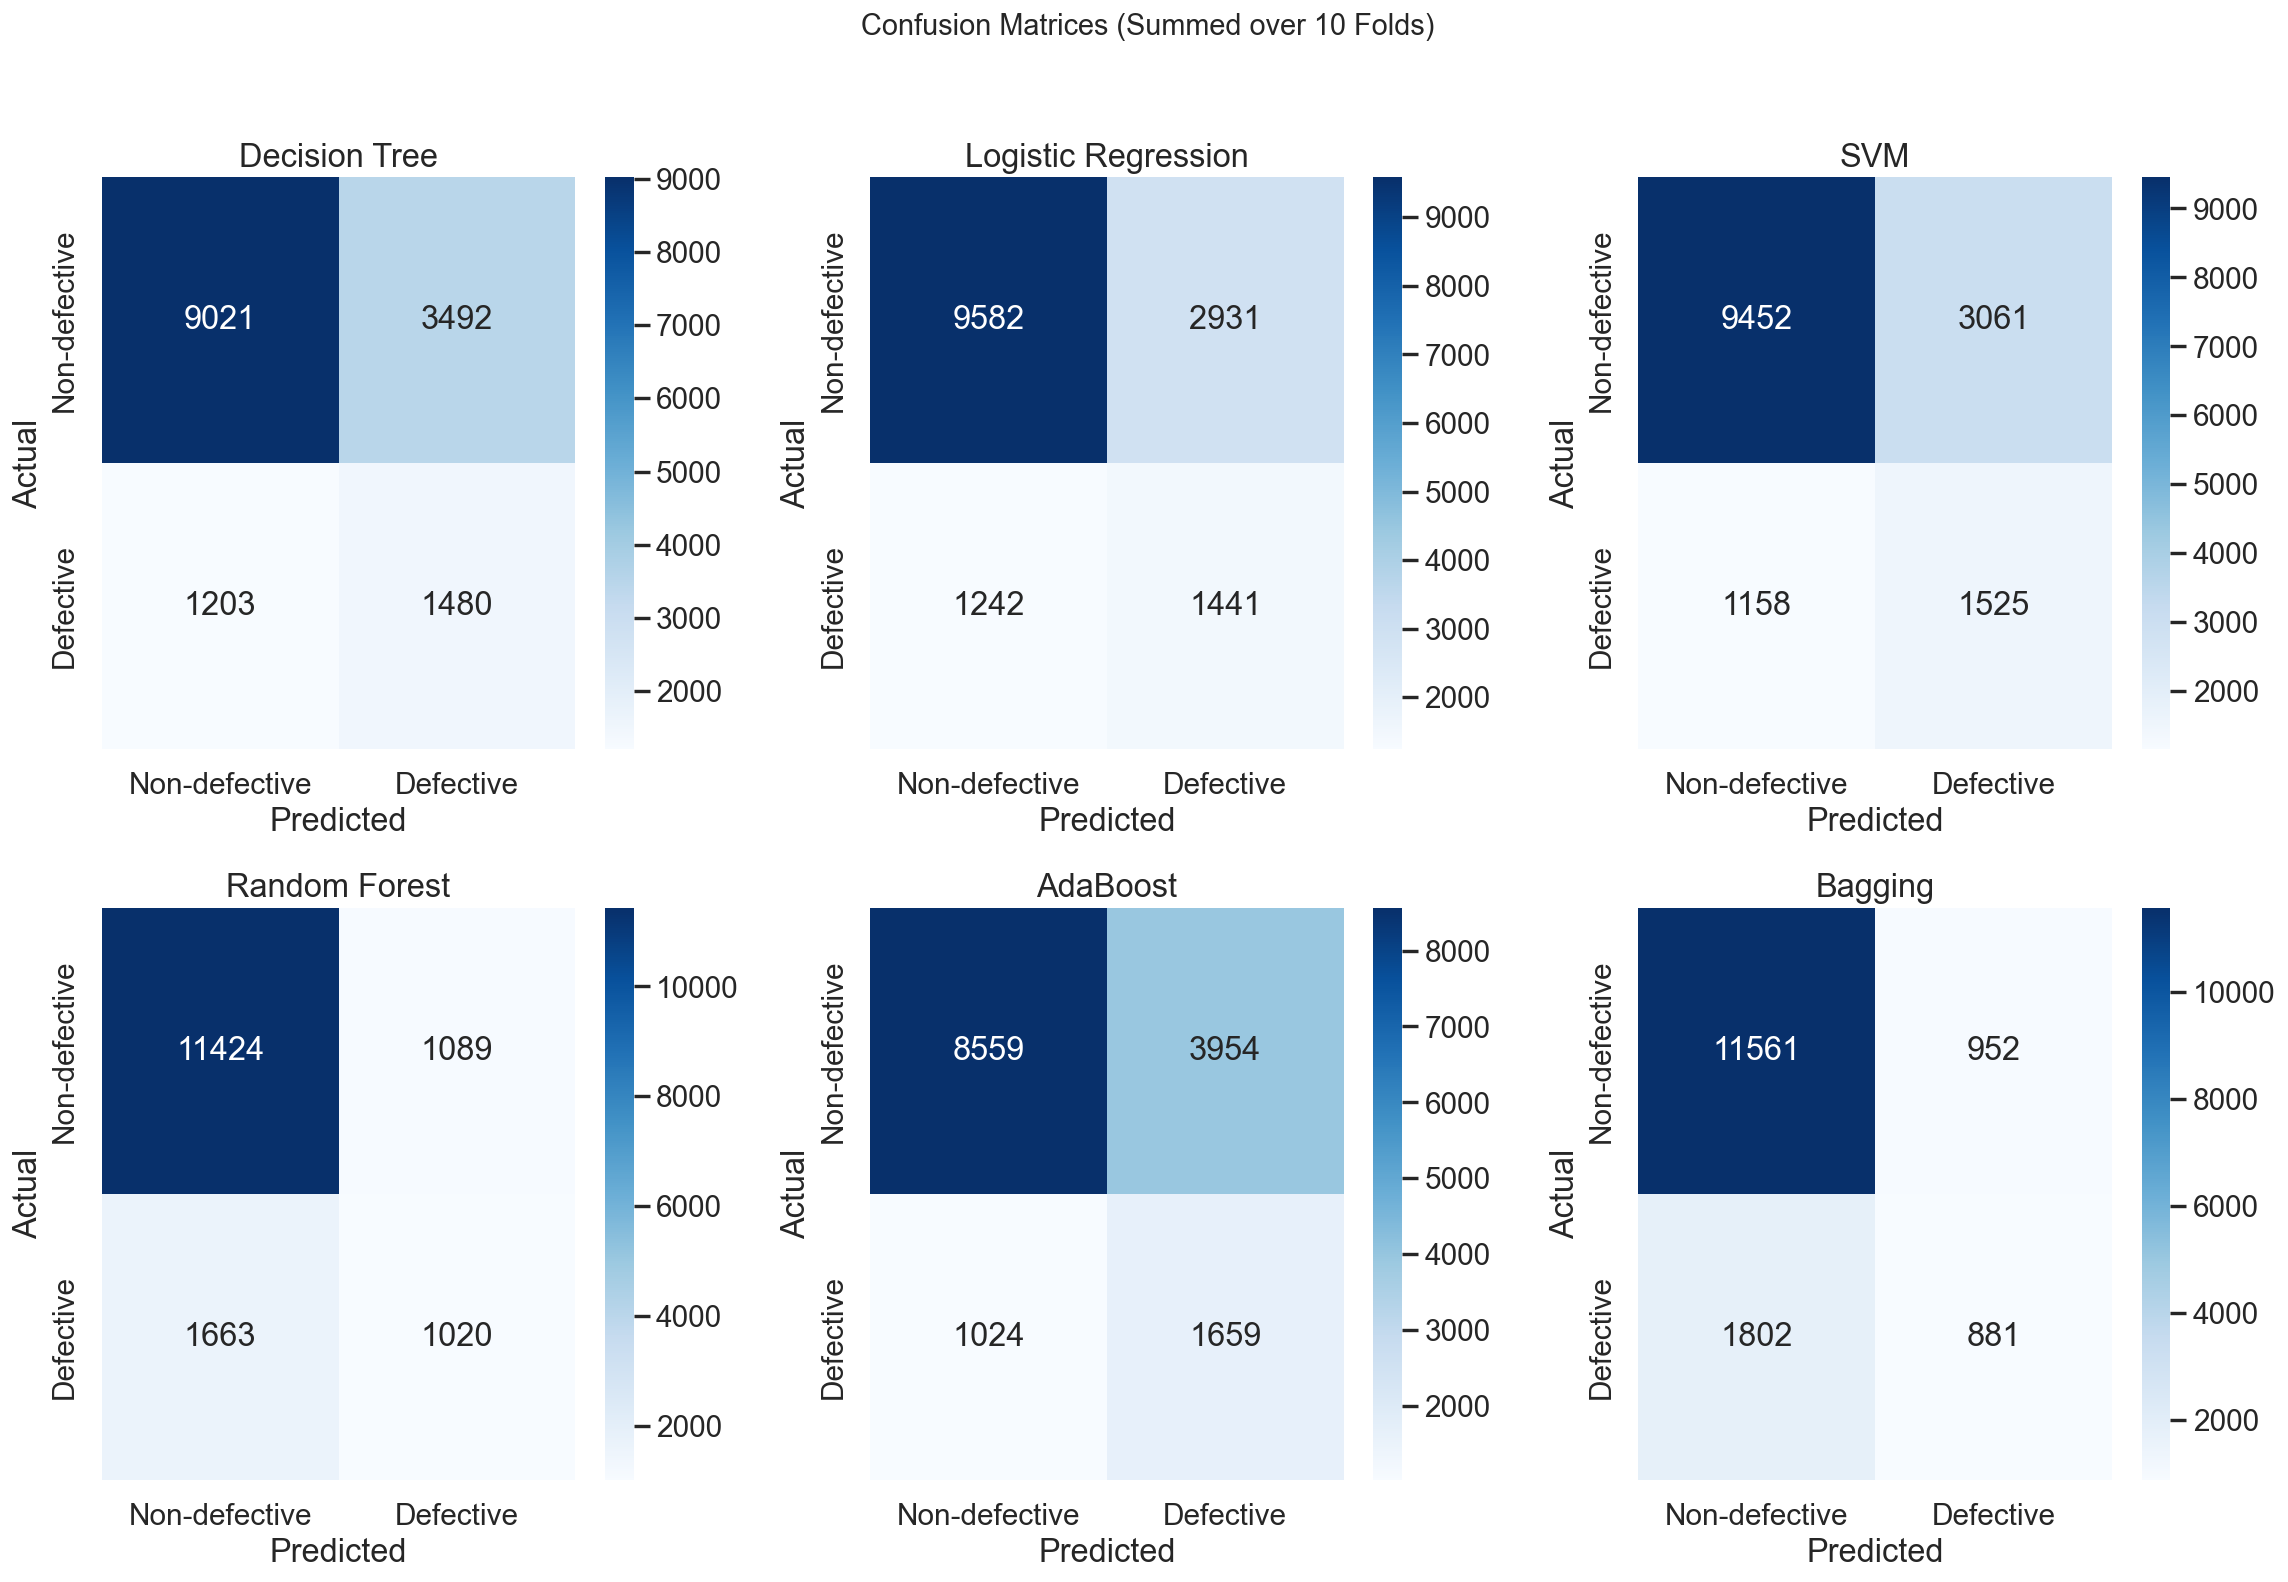

In [17]:
model_names = confusion_df['model'].tolist()
n_models = len(model_names)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, row in confusion_df.iterrows():
    cm = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-defective', 'Defective'],
        yticklabels=['Non-defective', 'Defective'],
        ax=axes[i],
    )
    axes[i].set_title(row['model'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Summed over 10 Folds)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


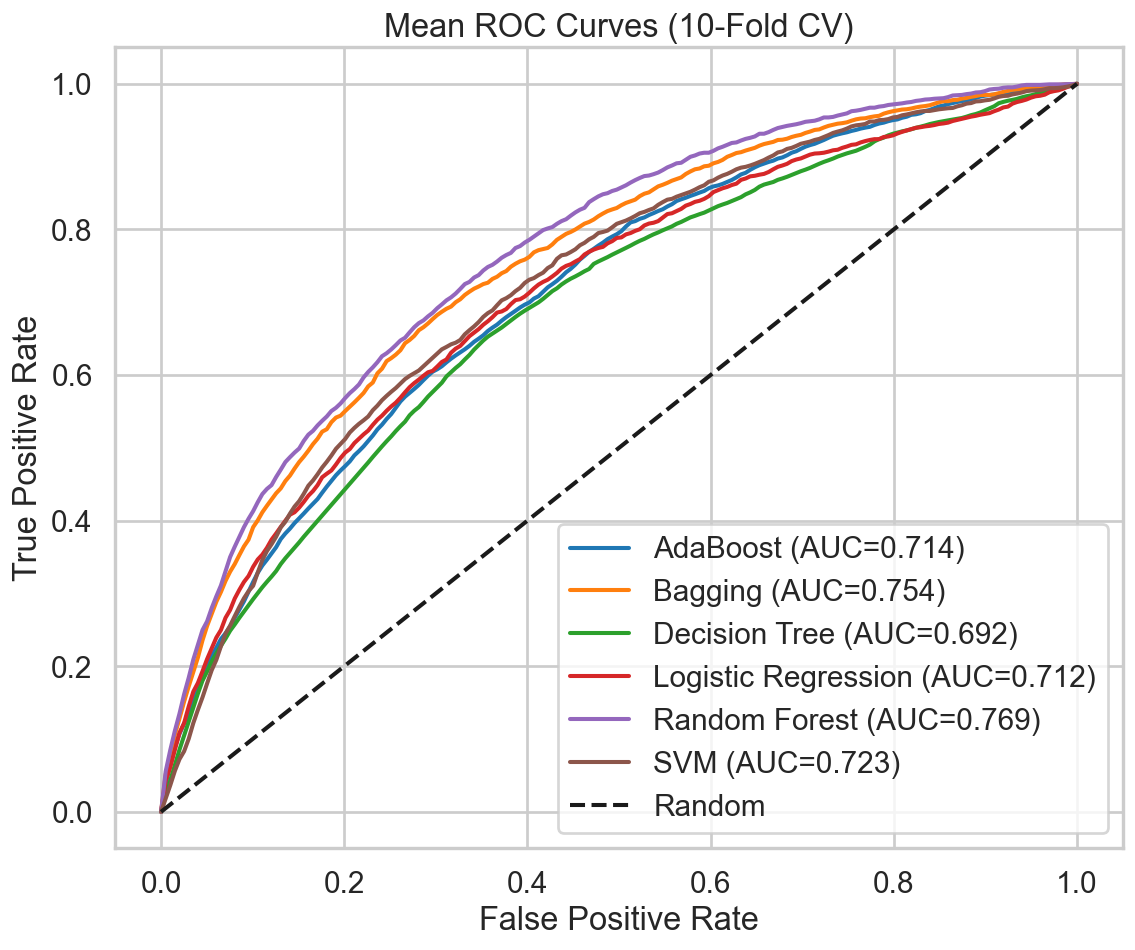

In [18]:
plt.figure(figsize=(10, 8))
palette = sns.color_palette('tab10', n_colors=roc_curve_df['model'].nunique())

for (model_name, group), color in zip(roc_curve_df.groupby('model'), palette):
    auc_val = summary_metrics_df.loc[summary_metrics_df['model'] == model_name, 'roc_auc_mean'].values[0]
    plt.plot(group['fpr'], group['tpr'], label=f'{model_name} (AUC={auc_val:.3f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Curves (10-Fold CV)')
plt.legend(loc='lower right')
plt.show()


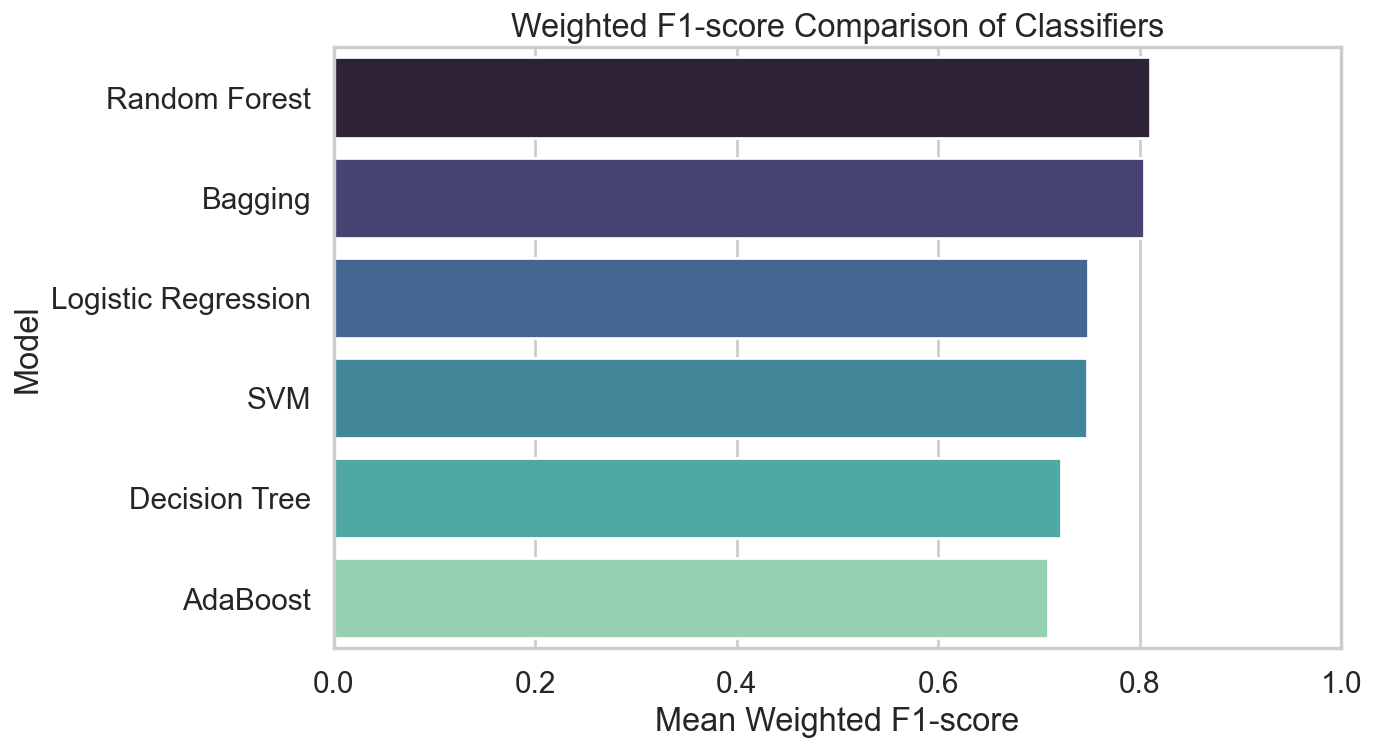

In [19]:
plt.figure(figsize=(10, 6))
plot_df = summary_metrics_df.sort_values(by='f1_weighted_mean', ascending=False)
sns.barplot(data=plot_df, x='f1_weighted_mean', y='model', hue='model', palette='mako', legend=False)
plt.title('Weighted F1-score Comparison of Classifiers')
plt.xlabel('Mean Weighted F1-score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()